# Equazioni non lineari

Questo notebook presenta i principali metodi numerici per la risoluzione di equazioni non lineari.  
L'obiettivo è mostrare non solo le formule dei metodi, ma anche il significato numerico, le ipotesi di convergenza, i test di arresto e alcuni esempi implementati in Python.

Argomenti:

1. problema $f(x)=0$;
2. errore inerente e sensibilità della radice;
3. metodo di bisezione;
4. metodi di iterazione funzionale;
5. punti fissi e convergenza locale;
6. ordine di convergenza;
7. metodo di Newton;
8. radici semplici e radici multiple;
9. test di arresto;
10. applicazioni del metodo di Newton: radice quadrata, reciproco, radice $m$-esima;
11. metodo delle secanti;
12. zeri di polinomi;
13. metodo di Sturm;
14. esercizi ed esperimenti numerici.

In [41]:
import math
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=12, suppress=True)

# Parte I — Il problema $f(x)=0$

## 1. Equazioni non lineari

Il problema è determinare le radici di un'equazione non lineare

$$
f(x)=0,
$$

dove $f$ è una funzione reale di variabile reale.

Una radice, o zero, è un valore $x^{*}$ tale che

$$
f(x^{*})=0.
$$

Nelle applicazioni, raramente esiste una formula esplicita per calcolare $x^{*}$.  
Per questo motivo si usano **metodi numerici iterativi**.

Un metodo iterativo costruisce una successione

$$
x_0, x_1, x_2, \ldots
$$

che, sotto opportune ipotesi, converge alla radice desiderata:

$$
\lim_{k\to\infty}x_k=x^{*}.
$$

### Esempio introduttivo

Consideriamo

$$
f(x)=x^2-2.
$$

Le radici sono

$$
x=\pm\sqrt{2}.
$$

Se vogliamo approssimare la radice positiva, possiamo cercarla numericamente nell'intervallo $[1,2]$, perché

$$
f(1)=-1<0,
$$

mentre

$$
f(2)=2>0.
$$

Il cambio di segno suggerisce, per continuità, che esiste almeno uno zero fra 1 e 2.

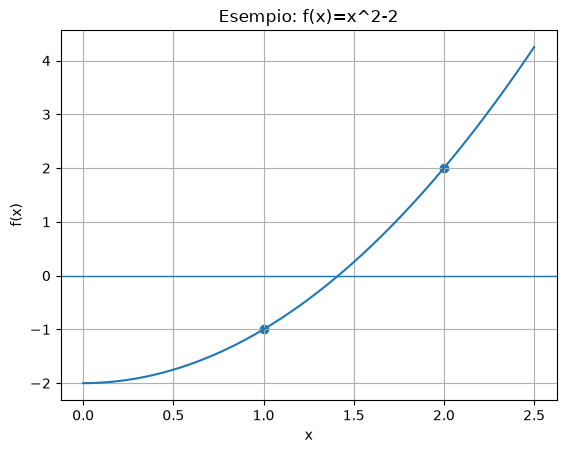

In [42]:
def f_intro(x):
    return x**2 - 2

xs = np.linspace(0, 2.5, 300)
ys = f_intro(xs)

plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(xs, ys)
plt.scatter([1, 2], [f_intro(1), f_intro(2)])
plt.title("Esempio: f(x)=x^2-2")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

### Numero di soluzioni di un'equazione non lineare

Un'equazione non lineare può avere comportamenti molto diversi rispetto al numero di soluzioni.

Una equazione del tipo

$$
f(x)=0
$$

può avere:

- nessuna soluzione reale;
- una sola soluzione reale;
- due o più soluzioni reali;
- un numero arbitrariamente grande di soluzioni;
- infinite soluzioni.

Questo è uno dei motivi per cui non esiste un unico metodo universale che risolva automaticamente tutte le equazioni non lineari.  
Prima di applicare un metodo numerico è spesso utile osservare il grafico della funzione o studiarne alcune proprietà qualitative.

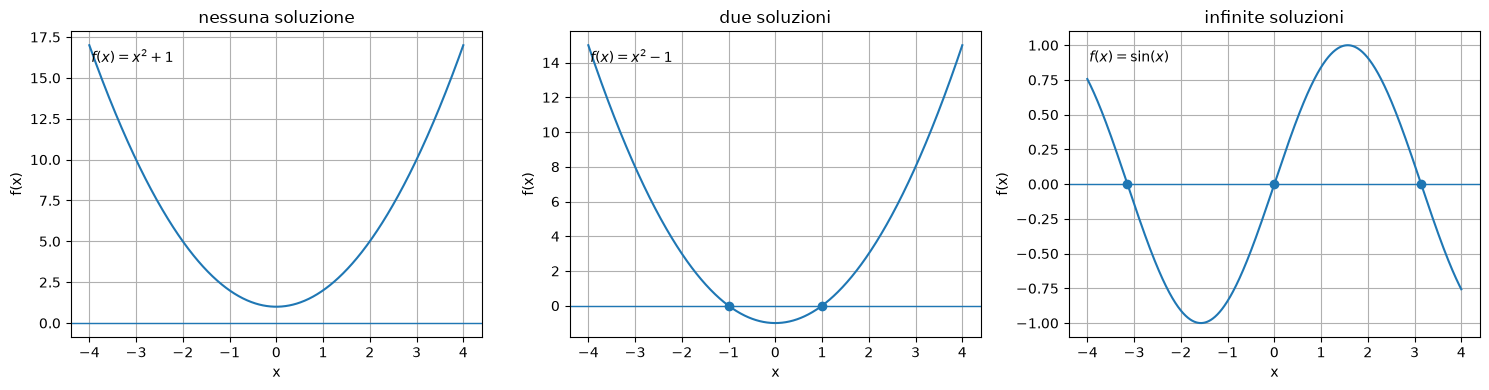

In [43]:
# Esempi di equazioni non lineari con diverso numero di soluzioni reali.

x = np.linspace(-4, 4, 800)

funzioni = [
    (lambda x: x**2 + 1, "nessuna soluzione", r"$f(x)=x^2+1$"),
    (lambda x: x**2 - 1, "due soluzioni", r"$f(x)=x^2-1$"),
    (lambda x: np.sin(x), "infinite soluzioni", r"$f(x)=\sin(x)$"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (f, titolo, formula) in zip(axes, funzioni):
    y = f(x)
    ax.plot(x, y)
    ax.axhline(0, linewidth=1)
    ax.set_title(titolo)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True)
    ax.text(0.05, 0.9, formula, transform=ax.transAxes)

    # Evidenziamo gli zeri visibili nei casi in cui sono noti.
    if titolo == "due soluzioni":
        ax.scatter([-1, 1], [0, 0], zorder=3)
    if titolo == "infinite soluzioni":
        zeri = np.arange(-3, 4) * np.pi
        zeri = zeri[(zeri >= x.min()) & (zeri <= x.max())]
        ax.scatter(zeri, np.zeros_like(zeri), zorder=3)

plt.tight_layout()
plt.show()

## 2. Perché servono metodi numerici

Una equazione come

$$
x^2-2=0
$$

ha una soluzione nota in forma chiusa.

Ma equazioni come

$$
\cos(x)-x=0,
$$

oppure

$$
e^{-x}-x=0,
$$

non hanno, in generale, una soluzione esprimibile con funzioni elementari.

In questi casi vogliamo calcolare una approssimazione $\tilde{x}$ tale che:

- $\tilde{x}$ sia vicina alla radice vera $x^{*}$;
- il _residuo_ $|f(\tilde{x})|$ sia piccolo;
- il calcolo sia stabile e non troppo costoso.

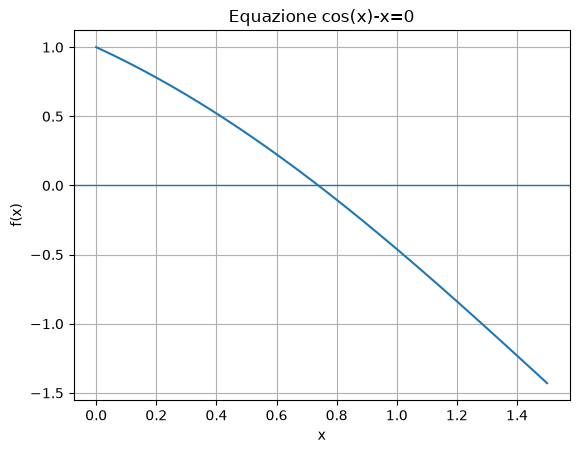

In [44]:
def f_cos(x):
    return np.cos(x) - x

xs = np.linspace(0, 1.5, 400)
ys = f_cos(xs)

plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(xs, ys)
plt.title("Equazione cos(x)-x=0")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

## 2bis. Molteplicità di una radice

Una radice $\alpha$ di una funzione $f$ è detta **radice di molteplicità** $m$ se si può scrivere

$$
f(x)=(x-\alpha)^m q(x),
$$

dove $q$ è una funzione continua e

$$
q(\alpha)\neq 0.
$$

In particolare:

- se $m=1$, la radice è **semplice**;
- se $m>1$, la radice è **multipla**.

Per i polinomi, questa definizione coincide con il numero di volte in cui il fattore $(x-\alpha)$ compare nella fattorizzazione.

### Caratterizzazione tramite derivate

Se $f$ è sufficientemente derivabile, allora $\alpha$ è una radice di molteplicità $m$ se

$$
f(\alpha)=f'(\alpha)=\cdots=f^{(m-1)}(\alpha)=0,
$$

ma

$$
f^{(m)}(\alpha)\neq 0.
$$

Ad esempio, per una radice doppia,

$$
f(\alpha)=0,\qquad f'(\alpha)=0,\qquad f''(\alpha)\neq 0.
$$

Le radici multiple sono importanti perché rendono più difficile il problema numerico: molti metodi, incluso Newton standard, convergono più lentamente in presenza di radici multiple.

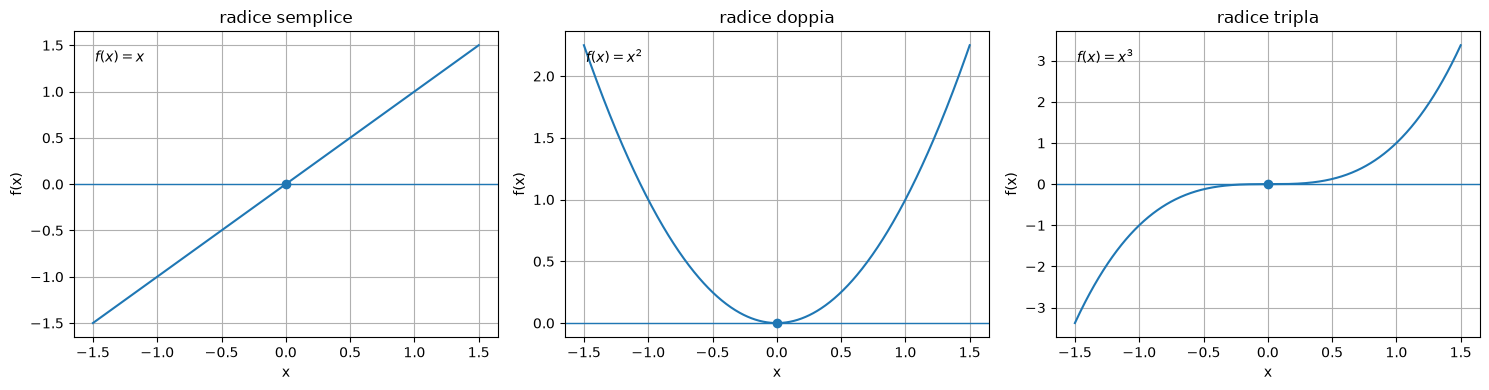

In [45]:
# Radici semplici, doppie e triple a confronto.

x = np.linspace(-1.5, 1.5, 600)
alpha = 0.0

f_simple = x
f_double = x**2
f_triple = x**3

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, f_simple)
axes[0].axhline(0, linewidth=1)
axes[0].scatter([alpha], [0], zorder=3)
axes[0].set_title("radice semplice")
axes[0].text(0.05, 0.9, r"$f(x)=x$", transform=axes[0].transAxes)

axes[1].plot(x, f_double)
axes[1].axhline(0, linewidth=1)
axes[1].scatter([alpha], [0], zorder=3)
axes[1].set_title("radice doppia")
axes[1].text(0.05, 0.9, r"$f(x)=x^2$", transform=axes[1].transAxes)

axes[2].plot(x, f_triple)
axes[2].axhline(0, linewidth=1)
axes[2].scatter([alpha], [0], zorder=3)
axes[2].set_title("radice tripla")
axes[2].text(0.05, 0.9, r"$f(x)=x^3$", transform=axes[2].transAxes)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Osservazione geometrica

Se la molteplicità è pari, la funzione spesso tocca l'asse $x$ senza attraversarlo.  
Questo significa che metodi basati sul cambio di segno, come la bisezione, possono non individuare direttamente la radice.

Se la molteplicità è dispari, la funzione attraversa l'asse $x$, ma può farlo in modo molto piatto.  
Anche in questo caso il problema può essere più difficile numericamente.

# Parte II — Errore inerente

## 3. Dati esatti e dati perturbati

In aritmetica finita, la funzione effettivamente valutata può non coincidere esattamente con la funzione matematica $f$.

Indichiamo con $\hat{f}$ la funzione perturbata, cioè quella realmente rappresentata o valutata dal calcolatore.

*Esempio: per un polinomio $f(x)=ax^2+bx+c$, avremo $\hat{f}(x)=\hat{a}x^2+\hat{b}x+\hat{c}$ dove $\hat{a}$, $\hat{b}$ e $\hat{c}$ sono le rappresentazioni in aritmetica finita dei coefficienti.*

Se

$$
f(x^{*})=0
$$

e

$$
\hat{f}(\hat{x}^{*})=0,
$$

allora $x^{*}$ è la radice del problema ideale, mentre $\hat{x}^{*}$ è la radice del problema perturbato.

Definiamo l'**errore sui dati** come

$$
E(x)=|\hat{f}(x)-f(x)|.
$$

Il problema è capire come l'errore su $f$ si trasmette alla radice.

## 4. Stima dell'errore sulla radice

Per il **teorema del valor medio**,

$$
\frac{f(\hat{x}^{*})-f(x^{*})}{\hat{x}^{*}-x^{*}}
=
f'(\omega),
$$

per un opportuno $\omega$ compreso fra $x^{*}$ e $\hat{x}^{*}$.

Poiché

$$
f(x^{*})=0
$$

e, usando $\hat{f}(\hat{x}^{*})=0$,

$$
E(\hat{x}^{*})=|\hat{f}(\hat{x}^{*})-f(\hat{x}^{*})|=|f(\hat{x}^{*})|,
$$

si ottiene

$$
|\hat{x}^{*}-x^{*}|
=
\frac{E(\hat{x}^{*})}{|f'(\omega)|}.
$$

Questa formula mostra che l'errore sulla radice dipende da due fattori:

1. l'errore di valutazione della funzione;
2. il valore di $|f'|$ vicino alla radice.

## 5. Interpretazione numerica

Se $|f'(x^{*})|$ è grande, una piccola perturbazione verticale della funzione produce una piccola perturbazione orizzontale della radice.

Se invece $|f'(x^{*})|$ è piccolo, anche una perturbazione piccola della funzione può spostare molto la radice.

Questo è particolarmente importante vicino a radici multiple, dove spesso la derivata si annulla.

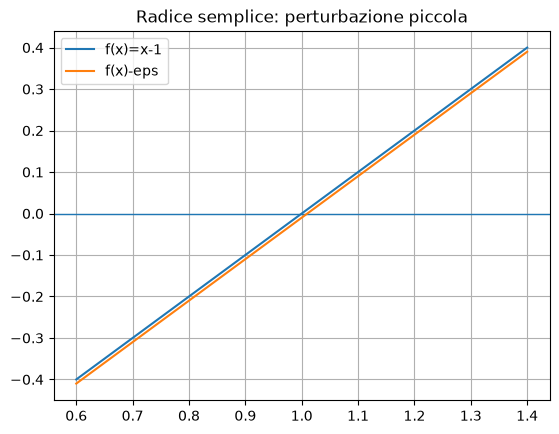

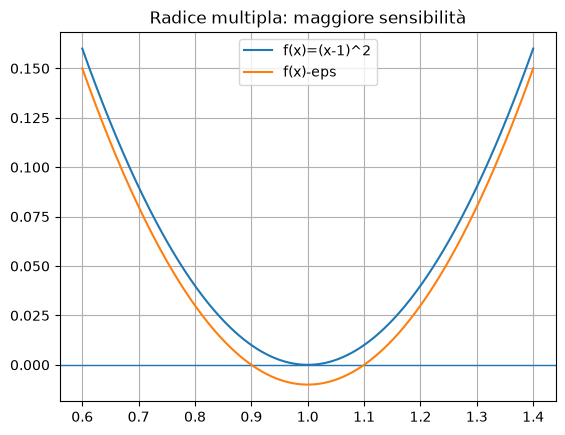

In [46]:
# Confronto visivo: radice semplice e radice doppia perturbate

def f_simple(x):
    return x - 1

def f_multiple(x):
    return (x - 1)**2

xs = np.linspace(0.6, 1.4, 400)
eps = 0.01

plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(xs, f_simple(xs), label="f(x)=x-1")
plt.plot(xs, f_simple(xs)-eps, label="f(x)-eps")
plt.title("Radice semplice: perturbazione piccola")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(xs, f_multiple(xs), label="f(x)=(x-1)^2")
plt.plot(xs, f_multiple(xs)-eps, label="f(x)-eps")
plt.title("Radice multipla: maggiore sensibilità")
plt.legend()
plt.grid(True)
plt.show()

# Parte III — Metodo di bisezione

## 6. Teorema degli zeri

Sia $f$ continua in $[a,b]$.  
Se

$$
f(a)f(b)<0,
$$

allora esiste almeno un punto $x^{*}\in(a,b)$ tale che

$$
f(x^{*})=0.
$$

Il metodo di bisezione usa questa idea:

1. si parte da un intervallo $[a,b]$ in cui $f$ cambia segno;
2. si calcola il punto medio

$$
m=\frac{a+b}{2};
$$

3. si valuta $f(m)$;
4. si tiene il sottointervallo in cui continua a esserci un cambio di segno;
5. si ripete.

## 7. Algoritmo di bisezione

Dato $[a,b]$ con $f(a)f(b)<0$:

1. calcola $m=(a+b)/2$;
2. se $f(m)=0$, allora $m$ è la radice;
3. se $f(a)f(m)<0$, sostituisci $b$ con $m$;
4. altrimenti sostituisci $a$ con $m$;
5. ripeti finché l'intervallo è sufficientemente piccolo.

A ogni iterazione la lunghezza dell'intervallo viene dimezzata.

Dopo $k$ iterazioni,

$$
b_k-a_k=\frac{b_0-a_0}{2^k}.
$$

Quindi l'errore sull'approssimazione data dal punto medio è al più

$$
\frac{b_k-a_k}{2}=\frac{b_0-a_0}{2^{k+1}}.
$$

In [47]:
def bisection(f, a, b, tol=1e-12, max_iter=100, return_history=False):
    fa = f(a)
    fb = f(b)

    if fa == 0:
        return (a, 0, []) if return_history else (a, 0)
    if fb == 0:
        return (b, 0, []) if return_history else (b, 0)

    if fa * fb > 0:
        raise ValueError("La funzione deve cambiare segno in [a,b].")

    history = []

    for k in range(1, max_iter + 1):
        m = 0.5 * (a + b)
        fm = f(m)

        history.append((k, a, b, m, fm, b - a))

        if abs(b - a) <= tol or fm == 0:
            return (m, k, history) if return_history else (m, k)

        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return (0.5 * (a + b), max_iter, history) if return_history else (0.5 * (a + b), max_iter)

In [48]:
root, niter, hist = bisection(lambda x: x**2 - 2, 1, 2, tol=1e-12, return_history=True)

print("Radice approssimata:", root)
print("Iterazioni:", niter)
print("Errore rispetto a sqrt(2):", abs(root - math.sqrt(2)))

Radice approssimata: 1.414213562372879
Iterazioni: 41
Errore rispetto a sqrt(2): 2.1604940059205546e-13


## 8. Tabella delle iterazioni di bisezione

La tabella seguente mostra come si restringe l'intervallo.

In [49]:
for row in hist[:10]:
    k, a, b, m, fm, width = row
    print(f"k={k:2d}, a={a:.12f}, b={b:.12f}, m={m:.12f}, f(m)={fm:.3e}, ampiezza={width:.3e}")

k= 1, a=1.000000000000, b=2.000000000000, m=1.500000000000, f(m)=2.500e-01, ampiezza=1.000e+00
k= 2, a=1.000000000000, b=1.500000000000, m=1.250000000000, f(m)=-4.375e-01, ampiezza=5.000e-01
k= 3, a=1.250000000000, b=1.500000000000, m=1.375000000000, f(m)=-1.094e-01, ampiezza=2.500e-01
k= 4, a=1.375000000000, b=1.500000000000, m=1.437500000000, f(m)=6.641e-02, ampiezza=1.250e-01
k= 5, a=1.375000000000, b=1.437500000000, m=1.406250000000, f(m)=-2.246e-02, ampiezza=6.250e-02
k= 6, a=1.406250000000, b=1.437500000000, m=1.421875000000, f(m)=2.173e-02, ampiezza=3.125e-02
k= 7, a=1.406250000000, b=1.421875000000, m=1.414062500000, f(m)=-4.272e-04, ampiezza=1.562e-02
k= 8, a=1.414062500000, b=1.421875000000, m=1.417968750000, f(m)=1.064e-02, ampiezza=7.812e-03
k= 9, a=1.414062500000, b=1.417968750000, m=1.416015625000, f(m)=5.100e-03, ampiezza=3.906e-03
k=10, a=1.414062500000, b=1.416015625000, m=1.415039062500, f(m)=2.336e-03, ampiezza=1.953e-03


## 9. Numero di iterazioni richieste

Se vogliamo un errore finale di al più $\mathrm{tol}$, dobbiamo avere

$$
\frac{b_0-a_0}{2^{k+1}}\le \mathrm{tol}.
$$

Da cui

$$
k\ge \log_2\left(\frac{b_0-a_0}{2 \mathrm{tol}}\right).
$$

Quindi il numero di iterazioni cresce solo logaritmicamente rispetto alla tolleranza, ma il metodo rimane relativamente lento perché a ogni passo guadagna circa una cifra binaria.

In [50]:
def bisection_iterations_needed(a, b, tol):
    return math.ceil(math.log2((b - a) / tol))

for tol in [1e-3, 1e-6, 1e-9, 1e-12]:
    print(f"tol={tol:.0e}, iterazioni richieste circa:", bisection_iterations_needed(1, 2, tol))

tol=1e-03, iterazioni richieste circa: 10
tol=1e-06, iterazioni richieste circa: 20
tol=1e-09, iterazioni richieste circa: 30
tol=1e-12, iterazioni richieste circa: 40


## 10. Test di arresto e aritmetica finita

In aritmetica finita non ha senso chiedere una tolleranza arbitrariamente piccola.

Un test realistico tiene conto della precisione macchina.  
In Python, `np.finfo(float).eps` è la distanza relativa fra 1 e il successivo numero floating point rappresentabile.

Un test pratico è

$$
|b_k-a_k|
\le
\mathrm{TOL}
+
\varepsilon \min(|a_k|,|b_k|),
$$

dove $\varepsilon$ rappresenta una misura della precisione di macchina.

In [51]:
eps = np.finfo(float).eps
print("eps =", eps)

def bisection_safe(f, a, b, tol=1e-12, max_iter=100):
    fa = f(a)
    fb = f(b)

    if a < 0 < b and f(0.0) == 0:
        return 0.0, 0

    if fa * fb > 0:
        raise ValueError("La funzione deve cambiare segno in [a,b].")

    for k in range(1, max_iter + 1):
        m = 0.5 * (a + b)
        fm = f(m)

        if abs(b - a) <= tol + eps * min(abs(a), abs(b)) or fm == 0:
            return m, k

        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return 0.5 * (a + b), max_iter

root, it = bisection_safe(lambda x: x**2 - 2, 1, 2)
print(root, it)

eps = 2.220446049250313e-16
1.414213562372879 41


## 11. Limiti del metodo di bisezione

Vantaggi:

- è semplice;
- è robusto;
- converge sempre se $f$ è continua e cambia segno;
- non richiede di valutare la funzione, ma solo il suo segno;
- non richiede derivate.

Svantaggi:

- converge lentamente;
- usa solo il segno di $f$, non la sua forma. Di conseguenza può richiedere infinite iterazioni per calcolare lo zero di una retta $f(x)=ax+b$;
- se in un intervallo ci sono più radici, ne approssima una sola;
- non funziona direttamente per radici di molteplicità pari se non c'è cambio di segno.

In [52]:
# Esempio di radice doppia: nessun cambio di segno
def f_double(x):
    return (x - 1)**2

print("f(0) =", f_double(0))
print("f(2) =", f_double(2))
print("Prodotto:", f_double(0) * f_double(2))

f(0) = 1
f(2) = 1
Prodotto: 1


# Parte IV — Iterazione funzionale

## 12. Da $f(x)=0$ a $x=g(x)$

Un metodo di iterazione funzionale costruisce una successione

$$
x_{k+1}=g(x_k),
\qquad k=0,1,2,\ldots
$$

Una soluzione dell'equazione

$$
x=g(x)
$$

si chiama punto fisso di $g$.

Per usare questo schema per risolvere

$$
f(x)=0,
$$

si trasforma il problema in una forma equivalente

$$
x=g(x).
$$

Per esempio, scegliendo una funzione $h(x)\neq 0$ si può porre

$$
g(x)=x-\frac{f(x)}{h(x)}.
$$

Allora

$$
x=g(x)
$$

equivale a

$$
f(x)=0.
$$

In [53]:
def fixed_point(g, x0, tol=1e-12, max_iter=100, return_history=False):
    x = float(x0)
    history = [x]

    for k in range(1, max_iter + 1):
        x_new = g(x)
        history.append(x_new)

        if abs(x_new - x) <= tol:
            return (x_new, k, history) if return_history else (x_new, k)

        x = x_new

    return (x, max_iter, history) if return_history else (x, max_iter)

## 13. Esempio: $x=\cos(x)$

L'equazione

$$
\cos(x)-x=0
$$

può essere scritta come

$$
x=\cos(x).
$$

Quindi usiamo

$$
g(x)=\cos(x).
$$

In [54]:
root, it, hist = fixed_point(np.cos, x0=1.0, tol=1e-12, return_history=True)

print("Punto fisso:", root)
print("Iterazioni:", it)
print("Residuo cos(x)-x:", math.cos(root) - root)

for k, xk in enumerate(hist[:10]):
    print(f"k={k:2d}, x_k={xk:.12f}")

Punto fisso: 0.7390851332147725
Iterazioni: 69
Residuo cos(x)-x: 6.495914917081791e-13
k= 0, x_k=1.000000000000
k= 1, x_k=0.540302305868
k= 2, x_k=0.857553215846
k= 3, x_k=0.654289790498
k= 4, x_k=0.793480358743
k= 5, x_k=0.701368773623
k= 6, x_k=0.763959682901
k= 7, x_k=0.722102425027
k= 8, x_k=0.750417761764
k= 9, x_k=0.731404042423


### Interpretazione grafica dell'equazione $\cos(x)-x=0$

L'equazione

$$
\cos(x)-x=0
$$

può essere vista in due modi equivalenti:

1. come ricerca dello zero della funzione $f(x)=\cos(x)-x$;
2. come ricerca del punto fisso della funzione $g(x)=\cos(x)$, cioè dell'intersezione fra $y=\cos(x)$ e $y=x$.

I due grafici seguenti mostrano le due interpretazioni.

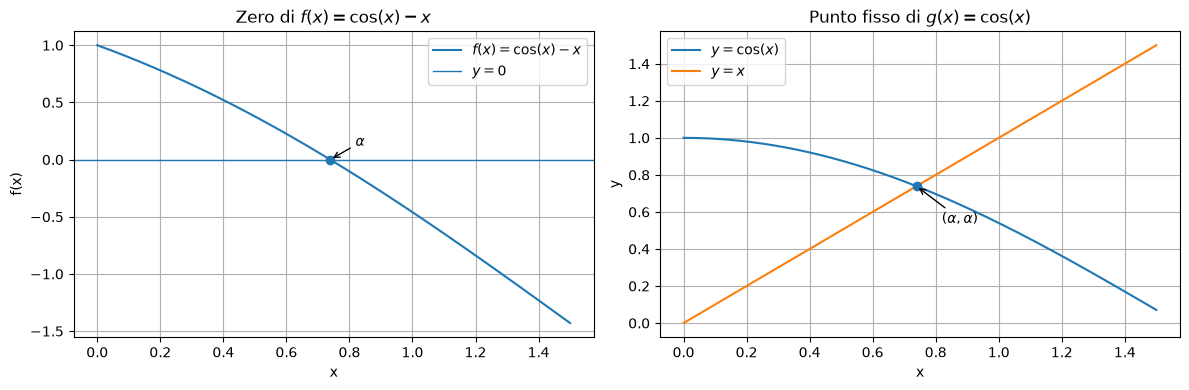

In [55]:
# Confronto tra la formulazione f(x)=0 e la formulazione x=g(x).

alpha = 0.7390851332151607
x = np.linspace(0, 1.5, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sinistra: zero di f(x)=cos(x)-x
axes[0].plot(x, np.cos(x) - x, label=r"$f(x)=\cos(x)-x$")
axes[0].axhline(0, linewidth=1, label=r"$y=0$")
axes[0].scatter([alpha], [0], zorder=3)
axes[0].annotate(r"$\alpha$", xy=(alpha, 0), xytext=(alpha+0.08, 0.12),
                 arrowprops=dict(arrowstyle="->"))
axes[0].set_title(r"Zero di $f(x)=\cos(x)-x$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)
axes[0].legend()

# Destra: punto fisso x=cos(x)
axes[1].plot(x, np.cos(x), label=r"$y=\cos(x)$")
axes[1].plot(x, x, label=r"$y=x$")
axes[1].scatter([alpha], [alpha], zorder=3)
axes[1].annotate(r"$(\alpha,\alpha)$", xy=(alpha, alpha), xytext=(alpha+0.08, alpha-0.2),
                 arrowprops=dict(arrowstyle="->"))
axes[1].set_title(r"Punto fisso di $g(x)=\cos(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Condizione di convergenza locale

Sia $x^{*}$ un punto fisso di $g$.

Se $g$ è derivabile in un intorno di $x^{*}$ e

$$
|g'(x)|\le \lambda < 1
$$

in tale intorno, allora l'iterazione

$$
x_{k+1}=g(x_k)
$$

converge localmente a $x^{*}$.

La stima fondamentale è

$$
|x_{k+1}-x^{*}|
=
|g(x_k)-g(x^{*})|
\le
\lambda |x_k-x^{*}|.
$$

Quindi

$$
|x_k-x^{*}|\le \lambda^k |x_0-x^{*}|.
$$

### Interpretazione geometrica dell'iterazione di punto fisso

L'iterazione

$$
x_{k+1}=g(x_k)
$$

può essere rappresentata graficamente usando il diagramma a ragnatela, o *cobweb plot*.

Si disegnano:

- la curva $y=g(x)$;
- la retta $y=x$;
- passaggi verticali fino alla curva;
- passaggi orizzontali fino alla retta $y=x$.

Il punto fisso $\alpha$ è l'intersezione fra $y=g(x)$ e $y=x$.

Il comportamento dipende dal valore di $g'(\alpha)$:

- se $0<g'(\alpha)<1$, la convergenza è monotona;
- se $-1<g'(\alpha)<0$, la convergenza è oscillante;
- se $g'(\alpha)>1$, si ha divergenza monotona;
- se $g'(\alpha)<-1$, si ha divergenza oscillante.

```{figure} fig_eq_nonlin/figura1.png
---
width: 100%
align: center
---
```

<p align="center">
  <img src="fig_eq_nonlin\figura1.png"  width="900">
  <p align="center">
</p>

### Interpretazione

La quantità $|g'(x^{*})|$ determina il comportamento locale:

- se $|g'(x^{*})|<1$, ci aspettiamo convergenza locale;
- se $|g'(x^{*})|>1$, ci aspettiamo divergenza;
- se $g'(x^{*})<0$, gli iterati tendono a oscillare attorno al punto fisso;
- se $g'(x^{*})>0$, gli iterati si avvicinano senza alternare lato.

In [56]:
# Confronto di due iterazioni per risolvere x^2-2=0

sqrt2 = math.sqrt(2)

# g1 deriva da x = 0.5*(x + 2/x), metodo di Erone/Newton per sqrt(2)
def g1(x):
    return 0.5 * (x + 2/x)

# g2: trasformazione x = x - alpha*(x^2-2), con alpha scelto male
def g2(x):
    alpha = 1.0
    return x - alpha * (x**2 - 2)

for name, g in [("g1", g1), ("g2", g2)]:
    try:
        root, it, hist = fixed_point(g, 1.5, tol=1e-12, max_iter=20, return_history=True)
        print(name, "ultimo valore:", hist[-1], "iterazioni:", it, "errore:", abs(hist[-1] - sqrt2))
        print("  primi valori:", [round(v, 8) for v in hist[:6]])
    except Exception as e:
        print(name, "errore:", e)

g1 ultimo valore: 1.414213562373095 iterazioni: 5 errore: 2.220446049250313e-16
  primi valori: [1.5, 1.41666667, 1.41421569, 1.41421356, 1.41421356, 1.41421356]
g2 ultimo valore: -0.743429505278514 iterazioni: 20 errore: 2.157643067651609
  primi valori: [1.5, 1.25, 1.6875, 0.83984375, 2.13450623, -0.4216106]


# Parte V — Ordine di convergenza

## 15. Definizione di ordine di convergenza

Sia $x_k$ una successione che converge a $x^{*}$ e sia

$$
e_k=x_k-x^{*}.
$$

Se esiste $p\ge 1$ tale che

$$
\lim_{k\to\infty}
\frac{|e_{k+1}|}{|e_k|^p}
=
\gamma,
$$

allora la successione ha ordine di convergenza $p$ e $\gamma$ è il fattore di convergenza.

Terminologia:

- $p=1$ e $0<\gamma<1$: convergenza lineare;
- $p=1$ e $\gamma=1$: convergenza sublineare;
- $p>1$: convergenza superlineare;
- $p=2$: convergenza quadratica.

## 16. Significato pratico

Se la convergenza è lineare,

$$
|e_{k+1}|\approx \gamma |e_k|.
$$

L'errore viene moltiplicato circa per una costante minore di uno a ogni iterazione.

Se la convergenza è quadratica,

$$
|e_{k+1}|\approx C |e_k|^2.
$$

Quando $|e_k|$ è piccolo, il quadrato è molto più piccolo: il numero di cifre corrette tende circa a raddoppiare a ogni iterazione.

In [57]:
# Simulazione di convergenza lineare e quadratica

errors_linear = [1e-1]
errors_quad = [1e-1]

for k in range(8):
    errors_linear.append(0.5 * errors_linear[-1])
    errors_quad.append(2.0 * errors_quad[-1]**2)

print("k   lineare        quadratica")
for k, (el, eq) in enumerate(zip(errors_linear, errors_quad)):
    print(f"{k:1d}   {el:.3e}      {eq:.3e}")

k   lineare        quadratica
0   1.000e-01      1.000e-01
1   5.000e-02      2.000e-02
2   2.500e-02      8.000e-04
3   1.250e-02      1.280e-06
4   6.250e-03      3.277e-12
5   3.125e-03      2.147e-23
6   1.563e-03      9.223e-46
7   7.813e-04      1.701e-90
8   3.906e-04      5.790e-180


## 17. Ordine di convergenza per iterazioni funzionali

Se $g$ è sufficientemente regolare e $x^{*}$ è un punto fisso, lo sviluppo di Taylor dà:

$$
g(x_k)-g(x^{*})
=
g'(x^{*})(x_k-x^{*})
+
\frac{g''(x^{*})}{2}(x_k-x^{*})^2
+
\cdots
+
\frac{g^{(p)}(x^{*})}{p!}(x_k-x^{*})^p
+
\cdots
$$

Se

$$
g'(x^{*})=g''(x^{*})=\cdots=g^{(p-1)}(x^{*})=0
$$

e

$$
g^{(p)}(x^{*})\neq 0,
$$

allora l'ordine di convergenza è $p$.

# Parte VI — Metodo di Newton

## 18. Derivazione del metodo di Newton

Supponiamo che $x_k$ sia una approssimazione della radice $x^{*}$.

Sviluppiamo $f$ in serie di Taylor attorno a $x_k$:

$$
f(x^{*})
=
f(x_k)
+
(x^{*}-x_k)f'(x_k)
+
\frac{(x^{*}-x_k)^2}{2}f''(\xi).
$$

Se $x_k$ è vicino alla radice, trascuriamo il termine quadratico:

$$
0
\approx
f(x_k)+(x^{*}-x_k)f'(x_k).
$$

Risolvendo rispetto a $x^{*}$:

$$
x^{*}
\approx
x_k-\frac{f(x_k)}{f'(x_k)}.
$$

Quindi definiamo l'iterazione di Newton:

$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.
$$

## 19. Interpretazione geometrica

Il metodo di Newton sostituisce la funzione con la retta tangente nel punto $x_k$.

La tangente a $f$ in $x_k$ è

$$
y=f(x_k)+f'(x_k)(x-x_k).
$$

L'intersezione della tangente con l'asse $x$ si ottiene imponendo $y=0$:

$$
0=f(x_k)+f'(x_k)(x_{k+1}-x_k),
$$

da cui

$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.
$$

### Grafico della tangente di Newton

Il grafico seguente mostra un singolo passo del metodo di Newton.

A partire da $x_0$, si costruisce la tangente alla curva $y=f(x)$ nel punto $(x_0,f(x_0))$.  
L'intersezione della tangente con l'asse $x$ è il nuovo iterato $x_1$.

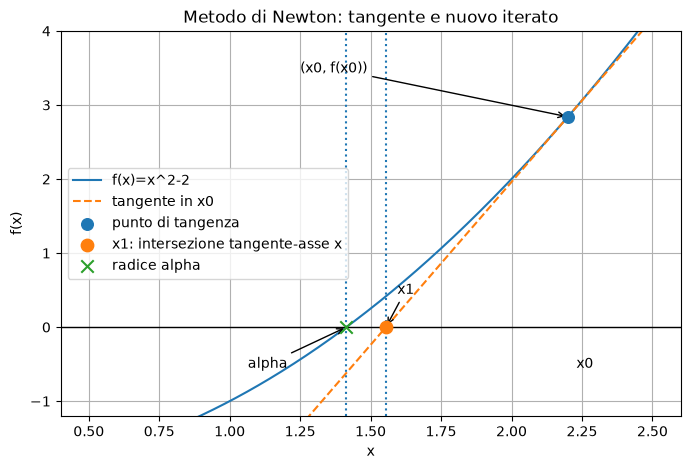

x0 = 2.2
x1 = 1.5545454545454547
radice alpha = 1.4142135623730951
|x1-alpha| = 0.14033189217235953


In [58]:
# Interpretazione geometrica di un passo del metodo di Newton.
# Scelgo x0=2.2, così il nuovo iterato x1 è ben distinto dalla radice sqrt(2).

f = lambda x: x**2 - 2
df = lambda x: 2*x

x0 = 2.2
x1 = x0 - f(x0)/df(x0)
alpha = math.sqrt(2)

xs = np.linspace(0.5, 2.5, 600)
tangent = f(x0) + df(x0) * (xs - x0)

plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label="f(x)=x^2-2")
plt.plot(xs, tangent, "--", label="tangente in x0")
plt.axhline(0, color="black", linewidth=1)

# Punti importanti
plt.scatter([x0], [f(x0)], s=70, zorder=4, label="punto di tangenza")
plt.scatter([x1], [0], s=80, zorder=5, label="x1: intersezione tangente-asse x")
plt.scatter([alpha], [0], s=80, marker="x", zorder=5, label="radice alpha")

# Linee verticali per rendere distinguibili x1 e alpha
plt.axvline(x1, linestyle=":", linewidth=1.5)
plt.axvline(alpha, linestyle=":", linewidth=1.5)

plt.annotate("x0", xy=(x0, 0), xytext=(x0+0.03, -0.55))
plt.annotate("x1", xy=(x1, 0), xytext=(x1+0.04, 0.45),
             arrowprops=dict(arrowstyle="->"))
plt.annotate("alpha", xy=(alpha, 0), xytext=(alpha-0.35, -0.55),
             arrowprops=dict(arrowstyle="->"))
plt.annotate("(x0, f(x0))", xy=(x0, f(x0)), xytext=(1.25, f(x0)+0.6),
             arrowprops=dict(arrowstyle="->"))

plt.title("Metodo di Newton: tangente e nuovo iterato")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.ylim(-1.2, 4.0)
plt.grid(True)
plt.legend()
plt.show()

print("x0 =", x0)
print("x1 =", x1)
print("radice alpha =", alpha)
print("|x1-alpha| =", abs(x1-alpha))

In [59]:
def newton(f, df, x0, tol_x=1e-12, tol_f=1e-14, max_iter=50, return_history=False):
    x_old = float(x0)
    history = [(0, x_old, f(x_old), None)]

    for k in range(1, max_iter + 1):
        fx = f(x_old)
        dfx = df(x_old)

        if abs(dfx) < np.finfo(float).tiny:
            raise ZeroDivisionError("Derivata troppo piccola o nulla.")

        x_new = x_old - fx / dfx
        step = abs(x_new - x_old)

        history.append((k, x_new, f(x_new), step))

        if step <= tol_x + np.finfo(float).eps * min(abs(x_new), abs(x_old)):
            return (x_new, k, history, "step") if return_history else (x_new, k)
        if abs(f(x_new)) <= tol_f:
            return (x_new, k, history, "residual") if return_history else (x_new, k)

        x_old = x_new

    return (x_old, max_iter, history, "max_iter") if return_history else (x_old, max_iter)

In [60]:
f = lambda x: x**2 - 2
df = lambda x: 2*x

root, it, hist, reason = newton(f, df, x0=1.0, return_history=True)

print("Radice:", root)
print("Iterazioni:", it)
print("Motivo arresto:", reason)
print("Errore:", abs(root - math.sqrt(2)))

for k, xk, fxk, step in hist:
    print(f"k={k:2d}, x={xk:.15f}, f(x)={fxk:.3e}, step={step}")

Radice: 1.4142135623730951
Iterazioni: 5
Motivo arresto: residual
Errore: 0.0
k= 0, x=1.000000000000000, f(x)=-1.000e+00, step=None
k= 1, x=1.500000000000000, f(x)=2.500e-01, step=0.5
k= 2, x=1.416666666666667, f(x)=6.944e-03, step=0.08333333333333326
k= 3, x=1.414215686274510, f(x)=6.007e-06, step=0.002450980392156854
k= 4, x=1.414213562374690, f(x)=4.511e-12, step=2.123899820016817e-06
k= 5, x=1.414213562373095, f(x)=4.441e-16, step=1.5947243525715749e-12


## 20. Convergenza locale del metodo di Newton

Newton è un caso particolare di iterazione funzionale con

$$
g(x)=x-\frac{f(x)}{f'(x)}.
$$

Derivando,

$$
g'(x)=
\frac{f(x)f''(x)}{[f'(x)]^2}.
$$

Se $x^{*}$ è una radice semplice, cioè

$$
f(x^{*})=0,\qquad f'(x^{*})\neq 0,
$$

allora

$$
g'(x^{*})=0.
$$

Questo spiega perché Newton ha convergenza almeno quadratica vicino a una radice semplice.

## 21. Ordine quadratico di Newton

Se $f$ è sufficientemente regolare e $x^{*}$ è una radice semplice, allora Newton ha ordine di convergenza 2.

Più precisamente,

$$
|e_{k+1}|
\approx
\frac{1}{2}
\left|
\frac{f''(x^{*})}{f'(x^{*})}
\right|
|e_k|^2.
$$

Quindi, quando si è abbastanza vicini alla radice, il numero di cifre corrette tende circa a raddoppiare a ogni iterazione.

In [61]:
# Verifica numerica del comportamento quadratico per sqrt(2)

xstar = math.sqrt(2)
f = lambda x: x**2 - 2
df = lambda x: 2*x

root, it, hist, _ = newton(f, df, x0=1.5, return_history=True)

print("k  errore           rapporto |e_{k+1}|/|e_k|^2")
errors = [abs(xk - xstar) for k, xk, fxk, step in hist]

for k in range(len(errors) - 1):
    if errors[k] != 0:
        ratio = errors[k+1] / (errors[k]**2)
        print(f"{k:1d}  {errors[k]:.3e}      {ratio:.6f}")

k  errore           rapporto |e_{k+1}|/|e_k|^2
0  8.579e-02      0.333333
1  2.453e-03      0.352941
2  2.124e-06      0.353522
3  1.595e-12      0.000000


## 22. Radici multiple

Se $x^{*}$ è una radice di molteplicità $m>1$, allora

$$
f(x)=(x-x^{*})^m q(x),
\qquad
q(x^{*})\neq 0.
$$

In questo caso Newton perde la convergenza quadratica e diventa in generale solo lineare.

Si può mostrare che

$$
g'(x^{*})=1-\frac{1}{m}.
$$

Quindi, se $m=2$,

$$
g'(x^{*})=\frac{1}{2}.
$$

Poichè la derivata ha valore assoluto minore di uno, ma è non nulla, la convergenza è solo lineare.

In [62]:
# Esempio: radice doppia in x=1
f = lambda x: (x - 1)**2
df = lambda x: 2*(x - 1)

xstar = 1.0
root, it, hist, reason = newton(f, df, x0=1.2, tol_x=1e-14, max_iter=20, return_history=True)

print("Radice:", root, "iterazioni:", it, "motivo:", reason)

print("k  x_k              errore       rapporto e_{k+1}/e_k")
errors = [abs(xk - xstar) for k, xk, fxk, step in hist]

for k in range(len(errors)-1):
    ratio = errors[k+1] / errors[k] if errors[k] != 0 else np.nan
    print(f"{k:2d} {hist[k][1]:.12f}  {errors[k]:.3e}  {ratio:.6f}")

Radice: 1.0000001907348632 iterazioni: 20 motivo: max_iter
k  x_k              errore       rapporto e_{k+1}/e_k
 0 1.200000000000  2.000e-01  0.500000
 1 1.100000000000  1.000e-01  0.500000
 2 1.050000000000  5.000e-02  0.500000
 3 1.025000000000  2.500e-02  0.500000
 4 1.012500000000  1.250e-02  0.500000
 5 1.006250000000  6.250e-03  0.500000
 6 1.003125000000  3.125e-03  0.500000
 7 1.001562500000  1.562e-03  0.500000
 8 1.000781250000  7.812e-04  0.500000
 9 1.000390625000  3.906e-04  0.500000
10 1.000195312500  1.953e-04  0.500000
11 1.000097656250  9.766e-05  0.500000
12 1.000048828125  4.883e-05  0.500000
13 1.000024414063  2.441e-05  0.500000
14 1.000012207031  1.221e-05  0.500000
15 1.000006103516  6.104e-06  0.500000
16 1.000003051758  3.052e-06  0.500000
17 1.000001525879  1.526e-06  0.500000
18 1.000000762939  7.629e-07  0.500000
19 1.000000381470  3.815e-07  0.500000


## 23. Newton modificato per radici multiple

Se la molteplicità $m$ della radice è nota, si può usare

$$
x_{k+1}=x_k-m\frac{f(x_k)}{f'(x_k)}.
$$

Per una radice di molteplicità $m$, questo metodo recupera la convergenza quadratica.

In [63]:
def newton_modified(f, df, x0, m, tol=1e-12, tol_f=1e-14, max_iter=50):
    x = float(x0)
    hist = [x]

    for k in range(max_iter):
        fx = f(x)

        # Se siamo già arrivati alla radice, ci fermiamo
        if abs(fx) <= tol_f:
            return x, k, hist

        dfx = df(x)

        # Evita divisioni per zero o per numeri troppo piccoli
        if abs(dfx) < 1e-15:
            raise ZeroDivisionError(
                "Derivata nulla o troppo piccola: il metodo non può proseguire."
            )

        x_new = x - m * fx / dfx
        hist.append(x_new)

        if abs(x_new - x) <= tol:
            return x_new, k + 1, hist

        x = x_new

    return x, max_iter, hist


# Esempio con radice doppia in x = 1
f = lambda x: (x - 1)**2 * (x + 2)

# Derivata:
# f(x) = (x - 1)^2 (x + 2)
# f'(x) = 2(x - 1)(x + 2) + (x - 1)^2
df = lambda x: 2*(x - 1)*(x + 2) + (x - 1)**2

root, it, hist_mod = newton_modified(f, df, x0=1.8, m=2)

print("Radice:", root)
print("Iterazioni:", it)
print("Iterati:")
for k, xk in enumerate(hist_mod):
    print(f"k={k:2d}, x_k={xk:.15f}, f(x_k)={f(xk):.3e}")

Radice: 1.0000000000000036
Iterazioni: 4
Iterati:
k= 0, x_k=1.800000000000000, f(x_k)=2.432e+00
k= 1, x_k=1.076190476190476, f(x_k)=1.786e-02
k= 2, x_k=1.000931993592544, f(x_k)=2.607e-06
k= 3, x_k=1.000000144701246, f(x_k)=6.282e-14
k= 4, x_k=1.000000000000004, f(x_k)=3.787e-29


## 24. Problemi pratici del metodo di Newton

Newton può essere molto veloce, ma non è globalmente convergente.

Può fallire se:

- $x_0$ è troppo lontano dalla radice;
- $f'(x_k)$ è molto piccolo;
- la tangente porta fuori dalla regione di interesse;
- la funzione ha più radici e si converge a quella “sbagliata”;
- la radice è multipla.

### Tre casi in cui Newton può fallire o comportarsi male

Il metodo di Newton è locale: funziona molto bene quando il punto iniziale è già sufficientemente vicino a una radice semplice, ma può fallire in altri casi.

I tre grafici seguenti mostrano situazioni tipiche:

1. ciclo: gli iterati possono rimbalzare fra pochi valori senza convergere;
2. derivata molto piccola: la tangente è quasi orizzontale e il nuovo iterato può essere molto lontano;
3. più radici: il metodo può convergere a una radice diversa da quella attesa.

<p align="center">
  <img src="fig_eq_nonlin\figura2.png"  width="700">
  <p align="center">
</p>

Per questo motivo, spesso si usa una strategia ibrida:

1. bisezione per localizzare una radice in modo robusto;
2. Newton per accelerare la convergenza quando si è vicini.

In [64]:
# Esempio in cui Newton può avere comportamento delicato
f = lambda x: x**3 - 2*x + 2
df = lambda x: 3*x**2 - 2

for x0 in [-2.0, 0.0, 0.5, 1.0, 2.0]:
    try:
        root, it, hist, reason = newton(f, df, x0=x0, max_iter=20, return_history=True)
        print(f"x0={x0: .2f} -> x={root:.12f}, f(x)={f(root):.3e}, it={it}, motivo={reason}")
    except Exception as e:
        print(f"x0={x0: .2f} -> errore: {e}")

x0=-2.00 -> x=-1.769292354239, f(x)=0.000e+00, it=5, motivo=step
x0= 0.00 -> x=0.000000000000, f(x)=2.000e+00, it=20, motivo=max_iter
x0= 0.50 -> x=-1.769292354239, f(x)=0.000e+00, it=9, motivo=residual
x0= 1.00 -> x=1.000000000000, f(x)=1.000e+00, it=20, motivo=max_iter
x0= 2.00 -> x=-1.769292354239, f(x)=0.000e+00, it=9, motivo=residual


# Parte VII — Test di arresto

## 26. Test di arresto per Newton

Un test ideale sarebbe

$$
\frac{|x_k-x^{*}|}{|x^{*}|}\le \mathrm{tol},
$$

ma $x^{*}$ non è noto.

Si usano quindi criteri pratici:

1. passo piccolo:

$$
|x_k-x_{k-1}|
\le
\mathrm{tol}_x+\varepsilon\min(|x_k|,|x_{k-1}|);
$$

2. residuo piccolo:

$$
|f(x_k)|\le \mathrm{tol}_f;
$$

3. limite massimo di iterazioni:

$$
k>\mathrm{maxIter}.
$$

È buona pratica usare più di un criterio.

### Perché controllare sia il passo sia il residuo

I criteri di arresto basati solo sul passo o solo sul residuo possono essere fuorvianti.

- Un residuo piccolo può non implicare una buona approssimazione della radice, soprattutto vicino a radici multiple o funzioni molto piatte.
- Un passo piccolo può indicare solo che la correzione di Newton è piccola, ma il residuo può essere ancora troppo grande rispetto alla scala richiesta.

Per questo è buona pratica controllare entrambi:

$$
|x_k-x_{k-1}|\le \mathrm{tol}_x
$$

e

$$
|f(x_k)|\le \mathrm{tol}_f.
$$

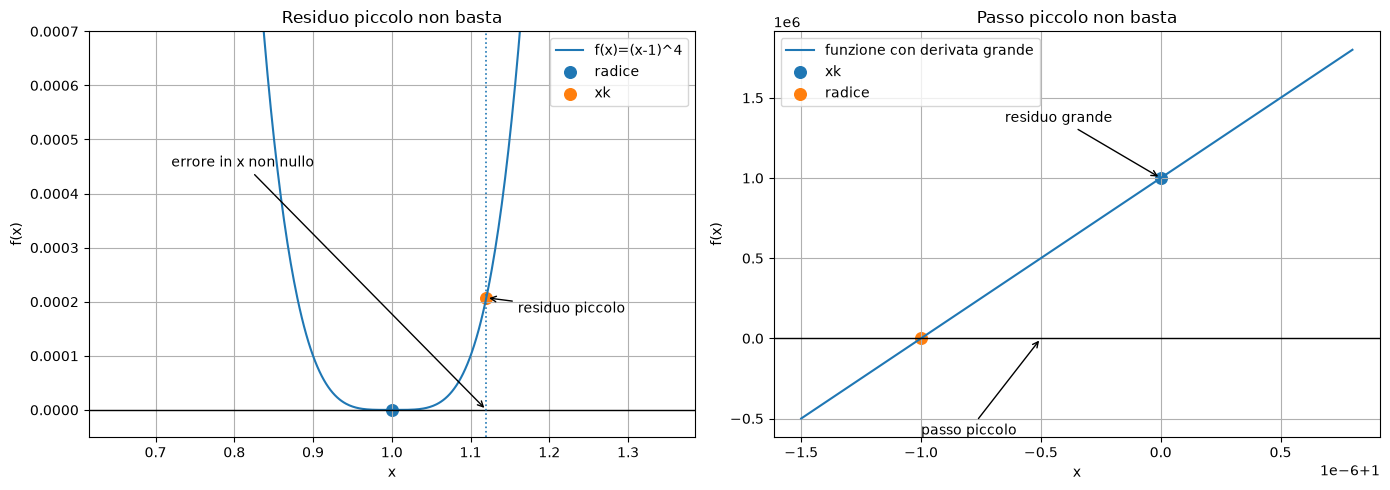

Caso A: xk = 1.12 residuo = 0.00020736000000000073 errore = 0.1200000000000001
Caso B: xk = 1.0 residuo = 1000000.0 passo Newton = 1e-06


In [65]:
# Perché usare sia il test sul passo sia il test sul residuo.
# Due esempi schematici robusti per VS Code.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Caso A: residuo piccolo ma punto ancora visibilmente lontano dalla radice,
# perché la funzione è molto piatta vicino alla radice.
fA = lambda x: (x - 1)**4
xA = np.linspace(0.65, 1.35, 500)
xk_A = 1.12

ax = axes[0]
ax.plot(xA, fA(xA), label="f(x)=(x-1)^4")
ax.axhline(0, color="black", linewidth=1)
ax.scatter([1.0], [0.0], s=70, label="radice")
ax.scatter([xk_A], [fA(xk_A)], s=70, label="xk")
ax.axvline(xk_A, linestyle=":", linewidth=1.2)
ax.annotate("residuo piccolo", xy=(xk_A, fA(xk_A)), xytext=(1.16, 0.00018),
            arrowprops=dict(arrowstyle="->"))
ax.annotate("errore in x non nullo", xy=(xk_A, 0), xytext=(0.72, 0.00045),
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Residuo piccolo non basta")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_ylim(-0.00005, 0.0007)
ax.grid(True)
ax.legend()

# Caso B: passo di Newton piccolo perché la derivata è molto grande,
# ma il residuo iniziale è grande.
fB = lambda x: 1e12*(x - 1) + 1e6
dfB = lambda x: 1e12 + 0*x
xk_B = 1.0
step_B = abs(fB(xk_B)/dfB(xk_B))
root_B = xk_B - fB(xk_B)/dfB(xk_B)

xB = np.linspace(0.9999985, 1.0000008, 500)
ax = axes[1]
ax.plot(xB, fB(xB), label="funzione con derivata grande")
ax.axhline(0, color="black", linewidth=1)
ax.scatter([xk_B], [fB(xk_B)], s=70, label="xk")
ax.scatter([root_B], [0.0], s=70, label="radice")
ax.annotate("passo piccolo", xy=((xk_B+root_B)/2, 0), xytext=(0.9999990, -6e5),
            arrowprops=dict(arrowstyle="->"))
ax.annotate("residuo grande", xy=(xk_B, fB(xk_B)), xytext=(0.99999935, 1.35e6),
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Passo piccolo non basta")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

print("Caso A: xk =", xk_A, "residuo =", fA(xk_A), "errore =", abs(xk_A - 1))
print("Caso B: xk =", xk_B, "residuo =", fB(xk_B), "passo Newton =", step_B)

In [66]:
def newton_with_report(f, df, x0, tol_x=1e-12, tol_f=1e-12, max_iter=50):
    x = float(x0)
    eps = np.finfo(float).eps

    print(f"{'k':>3} {'x_k':>20} {'f(x_k)':>15} {'step':>15}")

    for k in range(max_iter + 1):
        fx = f(x)

        if k == 0:
            print(f"{k:3d} {x:20.12e} {fx:15.6e} {'-':>15}")
        else:
            print(f"{k:3d} {x:20.12e} {fx:15.6e} {step:15.6e}")

        if abs(fx) <= tol_f:
            return x, k, "residuo"

        dfx = df(x)
        if abs(dfx) < np.finfo(float).tiny:
            return x, k, "derivata nulla"

        x_new = x - fx / dfx
        step = abs(x_new - x)

        if step <= tol_x + eps * min(abs(x_new), abs(x)):
            return x_new, k + 1, "passo"

        x = x_new

    return x, max_iter, "max_iter"

f = lambda x: x**2 - 2
df = lambda x: 2*x

root, it, reason = newton_with_report(f, df, 1.0)
print("\nRisultato:", root, "iterazioni:", it, "arresto:", reason)

  k                  x_k          f(x_k)            step
  0   1.000000000000e+00   -1.000000e+00               -
  1   1.500000000000e+00    2.500000e-01    5.000000e-01
  2   1.416666666667e+00    6.944444e-03    8.333333e-02
  3   1.414215686275e+00    6.007305e-06    2.450980e-03
  4   1.414213562375e+00    4.510614e-12    2.123900e-06
  5   1.414213562373e+00    4.440892e-16    1.594724e-12

Risultato: 1.4142135623730951 iterazioni: 5 arresto: residuo


# Parte VIII — Applicazioni di Newton

## 27. Calcolo di $\sqrt{a}$

Per calcolare la radice quadrata positiva di $a>0$, risolviamo

$$
x^2-a=0.
$$

Qui

$$
f(x)=x^2-a,
\qquad
f'(x)=2x.
$$

Newton dà

$$
x_{k+1}
=
x_k-\frac{x_k^2-a}{2x_k}
=
\frac{1}{2}
\left(
x_k+\frac{a}{x_k}
\right).
$$

Questa è la formula di Erone.

In [67]:
def sqrt_newton(a, x0=1.0, tol=1e-14, max_iter=50):
    if a < 0:
        raise ValueError("a deve essere non negativo.")
    if a == 0:
        return 0.0, 0, [0.0]

    x = float(x0)
    hist = [x]

    for k in range(1, max_iter + 1):
        x_new = 0.5 * (x + a / x)
        hist.append(x_new)

        if abs(x_new - x) <= tol:
            return x_new, k, hist

        x = x_new

    return x, max_iter, hist

a = 10
root, it, hist = sqrt_newton(a)

print("sqrt_newton:", root)
print("math.sqrt:", math.sqrt(a))
print("iterazioni:", it)
print("errore:", abs(root - math.sqrt(a)))

sqrt_newton: 3.162277660168379
math.sqrt: 3.1622776601683795
iterazioni: 7
errore: 4.440892098500626e-16


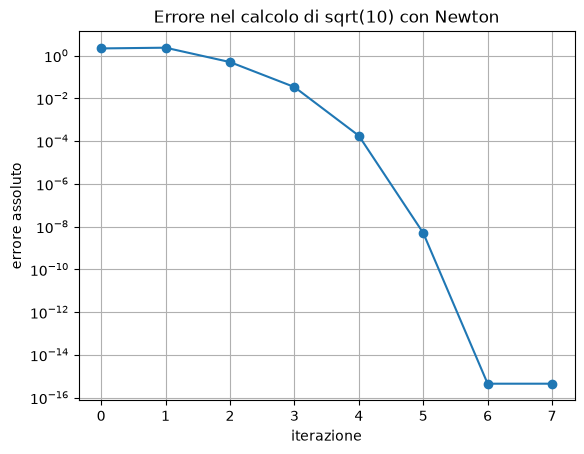

In [68]:
plt.figure()
plt.semilogy([abs(x - math.sqrt(10)) for x in hist], marker="o")
plt.title("Errore nel calcolo di sqrt(10) con Newton")
plt.xlabel("iterazione")
plt.ylabel("errore assoluto")
plt.grid(True)
plt.show()

## 28. Calcolo del reciproco $1/a$

Per calcolare il reciproco di $a$, si può risolvere

$$
\frac{1}{x}-a=0.
$$

Con

$$
f(x)=\frac{1}{x}-a,
\qquad
f'(x)=-\frac{1}{x^2},
$$

Newton dà

$$
x_{k+1}=x_k(2-ax_k).
$$

Questa formula usa solo moltiplicazioni e sottrazioni, ed è storicamente importante per implementare divisioni.

In [69]:
def reciprocal_newton(a, x0=None, tol=1e-14, max_iter=50):
    if a == 0:
        raise ZeroDivisionError("a non può essere zero.")

    if x0 is None:
        # Scelta semplice ma non ottimale.
        x = 1.0 / (2 ** math.ceil(math.log2(abs(a))))
        if a < 0:
            x = -x
    else:
        x = float(x0)

    hist = [x]

    for k in range(1, max_iter + 1):
        x_new = x * (2 - a * x)
        hist.append(x_new)

        if abs(x_new - x) <= tol:
            return x_new, k, hist

        x = x_new

    return x, max_iter, hist

a = 7.0
root, it, hist = reciprocal_newton(a)

print("reciproco Newton:", root)
print("1/a:", 1/a)
print("iterazioni:", it)
print("errore:", abs(root - 1/a))

reciproco Newton: 0.14285714285714285
1/a: 0.14285714285714285
iterazioni: 5
errore: 0.0


## 29. Radice $m$-esima

Per approssimare

$$
\sqrt[m]{a},
\qquad a>0,\quad m\ge 2,
$$

risolviamo

$$
x^m-a=0.
$$

Newton dà

$$
x_{k+1}
=
x_k-\frac{x_k^m-a}{m x_k^{m-1}}
=
\frac{1}{m}
\left[
(m-1)x_k+\frac{a}{x_k^{m-1}}
\right].
$$

In [70]:
def mth_root_newton(a, m, x0=1.0, tol=1e-14, max_iter=50):
    if a <= 0:
        raise ValueError("a deve essere positivo.")
    if m < 2:
        raise ValueError("m deve essere almeno 2.")

    x = float(x0)
    hist = [x]

    for k in range(1, max_iter + 1):
        x_new = ((m - 1) * x + a / (x ** (m - 1))) / m
        hist.append(x_new)

        if abs(x_new - x) <= tol:
            return x_new, k, hist

        x = x_new

    return x, max_iter, hist

a = 27
m = 3
root, it, hist = mth_root_newton(a, m)

print("Radice m-esima:", root)
print("Valore atteso:", a ** (1/m))
print("iterazioni:", it)

Radice m-esima: 3.0
Valore atteso: 3.0
iterazioni: 10


## 30. Esempio: $f(x)=x^3-3x+2$

Consideriamo

$$
f(x)=x^3-3x+2.
$$

Si fattorizza come

$$
f(x)=(x-1)^2(x+2).
$$

Quindi le radici sono:

- $x=-2$, radice semplice;
- $x=1$, radice doppia.

Newton dovrebbe convergere quadraticamente verso $-2$ e linearmente verso $1$.

In [71]:
f = lambda x: x**3 - 3*x + 2
df = lambda x: 3*x**2 - 3

# Radice semplice -2
root1, it1, hist1, reason1 = newton(f, df, x0=-2.4, max_iter=20, return_history=True)

# Radice doppia 1
root2, it2, hist2, reason2 = newton(f, df, x0=1.2, max_iter=20, return_history=True)

print("Radice semplice:")
print("  root =", root1, "it =", it1, "arresto =", reason1)

print("\nRadice doppia:")
print("  root =", root2, "it =", it2, "arresto =", reason2)

Radice semplice:
  root = -2.0 it = 5 arresto = residual

Radice doppia:
  root = 1.0000002031692978 it = 20 arresto = max_iter


In [72]:
def print_error_table(history, xstar, quadratic=False):
    errors = [abs(xk - xstar) for k, xk, fxk, step in history]
    for k in range(len(errors)-1):
        if quadratic:
            denom = errors[k]**2
            label = "|e_{k+1}|/|e_k|^2"
        else:
            denom = errors[k]
            label = "|e_{k+1}|/|e_k|"
        ratio = errors[k+1] / denom if denom != 0 else np.nan
        print(f"k={k:2d}, x={history[k][1]: .12f}, errore={errors[k]:.3e}, {label}={ratio:.6f}")

print("Verso -2, controllo quadratico:")
print_error_table(hist1, -2.0, quadratic=True)

print("\nVerso 1, controllo lineare:")
print_error_table(hist2, 1.0, quadratic=False)

Verso -2, controllo quadratico:
k= 0, x=-2.400000000000, errore=4.000e-01, |e_{k+1}|/|e_k|^2=0.476190
k= 1, x=-2.076190476190, errore=7.619e-02, |e_{k+1}|/|e_k|^2=0.619469
k= 2, x=-2.003596010676, errore=3.596e-03, |e_{k+1}|/|e_k|^2=0.664278
k= 3, x=-2.000008589972, errore=8.590e-06, |e_{k+1}|/|e_k|^2=0.666661
k= 4, x=-2.000000000049, errore=4.919e-11, |e_{k+1}|/|e_k|^2=0.000000

Verso 1, controllo lineare:
k= 0, x= 1.200000000000, errore=2.000e-01, |e_{k+1}|/|e_k|=0.515152
k= 1, x= 1.103030303030, errore=1.030e-01, |e_{k+1}|/|e_k|=0.508165
k= 2, x= 1.052356417198, errore=5.236e-02, |e_{k+1}|/|e_k|=0.504252
k= 3, x= 1.026400814055, errore=2.640e-02, |e_{k+1}|/|e_k|=0.502171
k= 4, x= 1.013257733872, errore=1.326e-02, |e_{k+1}|/|e_k|=0.501098
k= 5, x= 1.006643417773, errore=6.643e-03, |e_{k+1}|/|e_k|=0.500552
k= 6, x= 1.003325374626, errore=3.325e-03, |e_{k+1}|/|e_k|=0.500277
k= 7, x= 1.001663607293, errore=1.664e-03, |e_{k+1}|/|e_k|=0.500139
k= 8, x= 1.000832034087, errore=8.320e-04, |e

# Parte IX — Metodo delle secanti

## 31. Motivazione

Newton richiede la valutazione della derivata $f'(x)$.

In alcuni problemi:

- la derivata è costosa;
- la derivata non è disponibile;
- la funzione è data come procedura numerica o dati sperimentali.

Il metodo delle secanti sostituisce la derivata con un rapporto incrementale:

$$
f'(x_k)
\approx
\frac{f(x_k)-f(x_{k-1})}{x_k-x_{k-1}}.
$$

Sostituendo questa approssimazione nella formula di Newton si ottiene:

$$
x_{k+1}
=
x_k
-
f(x_k)
\frac{x_k-x_{k-1}}{f(x_k)-f(x_{k-1})}.
$$

## 32. Interpretazione geometrica

Newton usa la tangente alla curva nel punto $x_k$.

Il metodo delle secanti usa invece la retta secante passante per i due punti

$$
(x_{k-1},f(x_{k-1}))
$$

e

$$
(x_k,f(x_k)).
$$

Il nuovo iterato $x_{k+1}$ è l'intersezione di questa retta con l'asse $x$.

### Grafico della secante

Il metodo delle secanti sostituisce la tangente di Newton con la retta passante per due punti della curva:

$$
(x_{k-1},f(x_{k-1})),
\qquad
(x_k,f(x_k)).
$$

Il nuovo iterato $x_{k+1}$ è l'intersezione di questa retta con l'asse $x$.

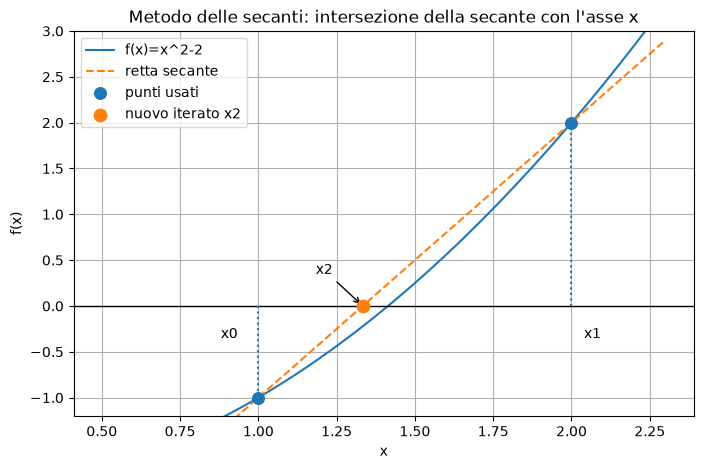

x0 = 1.0
x1 = 2.0
x2 = 1.3333333333333335


In [73]:
# Interpretazione geometrica del metodo delle secanti.

f_sec = lambda x: x**2 - 2

x0 = 1.0
x1 = 2.0
f0 = f_sec(x0)
f1 = f_sec(x1)

x2 = x1 - f1 * (x1 - x0) / (f1 - f0)

xs = np.linspace(0.5, 2.3, 500)
secant_line = f0 + (f1 - f0)/(x1 - x0) * (xs - x0)

plt.figure(figsize=(8, 5))
plt.plot(xs, f_sec(xs), label="f(x)=x^2-2")
plt.plot(xs, secant_line, "--", label="retta secante")
plt.axhline(0, color="black", linewidth=1)
plt.scatter([x0, x1], [f0, f1], s=70, zorder=4, label="punti usati")
plt.scatter([x2], [0], s=80, zorder=5, label="nuovo iterato x2")
plt.vlines([x0, x1], [0, 0], [f0, f1], linestyles=":")

plt.annotate("x0", xy=(x0, 0), xytext=(x0-0.12, -0.35))
plt.annotate("x1", xy=(x1, 0), xytext=(x1+0.04, -0.35))
plt.annotate("x2", xy=(x2, 0), xytext=(x2-0.15, 0.35),
             arrowprops=dict(arrowstyle="->"))

plt.title("Metodo delle secanti: intersezione della secante con l'asse x")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.ylim(-1.2, 3.0)
plt.grid(True)
plt.legend()
plt.show()

print("x0 =", x0)
print("x1 =", x1)
print("x2 =", x2)

In [74]:
def secant(f, x0, x1, tol_x=1e-12, tol_f=1e-14, max_iter=50, return_history=False):
    x_prev = float(x0)
    x_curr = float(x1)

    history = [(0, x_prev, f(x_prev), None),
               (1, x_curr, f(x_curr), abs(x_curr - x_prev))]

    for k in range(2, max_iter + 1):
        f_prev = f(x_prev)
        f_curr = f(x_curr)
        denom = f_curr - f_prev

        if abs(denom) < np.finfo(float).tiny:
            raise ZeroDivisionError("Denominatore quasi nullo nel metodo delle secanti.")

        x_new = x_curr - f_curr * (x_curr - x_prev) / denom
        step = abs(x_new - x_curr)

        history.append((k, x_new, f(x_new), step))

        if step <= tol_x + np.finfo(float).eps * min(abs(x_new), abs(x_curr)):
            return (x_new, k, history, "step") if return_history else (x_new, k)
        if abs(f(x_new)) <= tol_f:
            return (x_new, k, history, "residual") if return_history else (x_new, k)

        x_prev, x_curr = x_curr, x_new

    return (x_curr, max_iter, history, "max_iter") if return_history else (x_curr, max_iter)

In [75]:
f = lambda x: x**2 - 2

root, it, hist, reason = secant(f, 1.0, 2.0, return_history=True)

print("Radice:", root)
print("Iterazioni:", it)
print("Motivo arresto:", reason)
print("Errore:", abs(root - math.sqrt(2)))

for k, xk, fxk, step in hist:
    print(f"k={k:2d}, x={xk:.15f}, f(x)={fxk:.3e}, step={step}")

Radice: 1.4142135623730954
Iterazioni: 7
Motivo arresto: residual
Errore: 2.220446049250313e-16
k= 0, x=1.000000000000000, f(x)=-1.000e+00, step=None
k= 1, x=2.000000000000000, f(x)=2.000e+00, step=1.0
k= 2, x=1.333333333333333, f(x)=-2.222e-01, step=0.6666666666666665
k= 3, x=1.400000000000000, f(x)=-4.000e-02, step=0.06666666666666665
k= 4, x=1.414634146341463, f(x)=1.190e-03, step=0.014634146341463206
k= 5, x=1.414211438474870, f(x)=-6.007e-06, step=0.00042270786659326376
k= 6, x=1.414213562057320, f(x)=-8.931e-10, step=2.12358245033073e-06
k= 7, x=1.414213562373095, f(x)=8.882e-16, step=3.157749617344052e-10


## 33. Ordine di convergenza del metodo delle secanti

Per radici semplici e buoni punti iniziali, il metodo delle secanti ha ordine

$$
p=\frac{1+\sqrt{5}}{2}\approx 1.618.
$$

Questo valore è maggiore di 1, quindi la convergenza è superlineare, ma minore di 2, quindi più lenta di Newton vicino a una radice semplice.

Il vantaggio è che non richiede la derivata.

In [76]:
# Stima empirica dell'ordine di convergenza
xstar = math.sqrt(2)
errors = [abs(xk - xstar) for k, xk, fxk, step in hist if abs(xk - xstar) > 0]

print("Errori:", errors)

# Stima p_k = log(e_{k+1}/e_k) / log(e_k/e_{k-1})
for k in range(1, len(errors)-1):
    if errors[k-1] > 0 and errors[k] > 0 and errors[k+1] > 0:
        p_est = math.log(errors[k+1]/errors[k]) / math.log(errors[k]/errors[k-1])
        print(f"k={k}, p stimato = {p_est:.6f}")

Errori: [0.41421356237309515, 0.5857864376269049, 0.08088022903976166, 0.014213562373095012, 0.00042058396836819334, 2.1238982250704197e-06, 3.157747396898003e-10, 2.220446049250313e-16]
k=1, p stimato = -5.713032
k=2, p stimato = 0.878174
k=3, p stimato = 2.024593
k=4, p stimato = 1.502252
k=5, p stimato = 1.666619
k=6, p stimato = 1.607453


# Parte X — Metodi ibridi

## 34. Perché combinare bisezione e Newton

La bisezione è lenta ma robusta: se c'è cambio di segno, converge.

Newton è veloce ma locale: può divergere se il punto iniziale non è buono.

Una strategia pratica è:

1. usare bisezione per restringere l'intervallo;
2. passare a Newton quando il punto medio è abbastanza vicino alla radice.

Questa idea riflette l'osservazione che Newton è un metodo terminale veloce, mentre la bisezione è un metodo iniziale globale.

In [77]:
def hybrid_bisection_newton(f, df, a, b, n_bisect=10, tol=1e-12, max_newton=30):
    # Prima fase: alcune iterazioni di bisezione
    root_bis, _, hist_bis = bisection(f, a, b, tol=0.0, max_iter=n_bisect, return_history=True)
    x0 = root_bis

    # Seconda fase: Newton
    root_newton, it_newton, hist_newton, reason = newton(
        f, df, x0=x0, tol_x=tol, tol_f=tol, max_iter=max_newton, return_history=True
    )

    return root_newton, hist_bis, hist_newton, reason

f = lambda x: x**3 - x - 2
df = lambda x: 3*x**2 - 1

root, hist_bis, hist_newton, reason = hybrid_bisection_newton(f, df, 1, 2)

print("Radice:", root)
print("f(root):", f(root))
print("Iterazioni bisezione:", len(hist_bis))
print("Iterazioni Newton:", len(hist_newton)-1)
print("Arresto:", reason)

Radice: 1.5213797068045773
f(root): 5.773159728050814e-14
Iterazioni bisezione: 10
Iterazioni Newton: 2
Arresto: residual


# Parte XI — Zeri di polinomi

## 35. Polinomi e radici

Un polinomio di grado $n$ ha, contando le molteplicità, $n$ radici reali o complesse.

Se il polinomio ha coefficienti reali, le radici complesse compaiono in coppie coniugate.

Nelle applicazioni spesso interessa trovare solo le radici reali in un intervallo assegnato.  
Un approccio possibile è:

1. isolare gli intervalli che contengono radici reali;
2. applicare un metodo locale, come bisezione, Newton o secanti, per approssimarle.

### Idea generale: isolare e poi raffinare

Per trovare gli zeri reali di un polinomio è spesso utile separare il problema in due fasi:

1. **isolamento:** individuare intervalli che contengono una o più radici;
2. **raffinamento:** applicare un metodo numerico, come bisezione, Newton o secanti, su ciascun intervallo.

Il metodo di Sturm serve proprio per contare quante radici reali distinte si trovano in un intervallo.

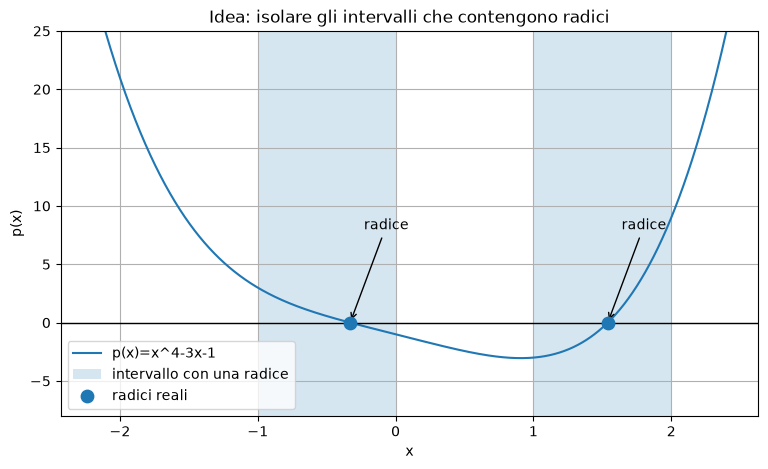

Radici reali approssimate: [-0.3294085281925508, 1.5396133460819756]
Intervalli isolanti: (-1, 0) e (1, 2)


In [78]:
# Esempio schematico: polinomio, radici reali e intervalli di isolamento.

def p_sturm_example_numeric(x):
    return x**4 - 3*x - 1

xs = np.linspace(-2.2, 2.4, 900)
ys = p_sturm_example_numeric(xs)

# Radici approssimate solo per visualizzazione.
roots = np.roots([1, 0, 0, -3, -1])
real_roots = sorted([float(r.real) for r in roots if abs(r.imag) < 1e-10])

plt.figure(figsize=(9, 5))
plt.plot(xs, ys, label="p(x)=x^4-3x-1")
plt.axhline(0, color="black", linewidth=1)

# Intervalli indicati dalla tabella di Sturm: (-1,0) e (1,2).
plt.axvspan(-1, 0, alpha=0.18, label="intervallo con una radice")
plt.axvspan(1, 2, alpha=0.18)
plt.scatter(real_roots, [0]*len(real_roots), s=80, zorder=4, label="radici reali")

for r in real_roots:
    plt.annotate("radice", xy=(r, 0), xytext=(r+0.1, 8),
                 arrowprops=dict(arrowstyle="->"))

plt.title("Idea: isolare gli intervalli che contengono radici")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.ylim(-8, 25)
plt.grid(True)
plt.legend()
plt.show()

print("Radici reali approssimate:", real_roots)
print("Intervalli isolanti: (-1, 0) e (1, 2)")

In [79]:
# Radici di un polinomio con NumPy
# p(x)=x^4-3x-1

coeff = [1, 0, 0, -3, -1]  # x^4 + 0x^3 + 0x^2 - 3x - 1
roots = np.roots(coeff)

print("Radici:")
for r in roots:
    print(r)

Radici:
(1.5396133460819756+0j)
(-0.6051024089447128+1.267126095639481j)
(-0.6051024089447128-1.267126095639481j)
(-0.3294085281925508+0j)


## 36. Metodo di Sturm

Il metodo di Sturm permette di determinare il numero di zeri reali distinti di un polinomio in un intervallo assegnato.

Sia dato un polinomio a coefficienti reali $p(x)$ e la sua derivata prima $p'(x)$.  
Si applica l'_algoritmo di Euclide_ in forma modificata.

Si divide $p(x)$ per $p'(x)$, ottenendo quoziente $q_1(x)$ e resto $r_1(x)$:

$$
p(x)=q_1(x)p'(x)+r_1(x).
$$

Si pone

$$
s_1(x)=-r_1(x).
$$

Poi si divide $p'(x)$ per $s_1(x)$:

$$
p'(x)=q_2(x)s_1(x)+r_2(x),
$$

e si pone

$$
s_2(x)=-r_2(x).
$$

Si prosegue dividendo $s_1(x)$ per $s_2(x)$:

$$
s_1(x)=q_3(x)s_2(x)+r_3(x),
$$

e così via, fino a ottenere l'ultimo polinomio non nullo.

La sequenza

$$
p(x),\ p'(x),\ s_1(x),\ s_2(x),\ldots,\ s_k(x)
$$

è detta **sequenza di Sturm**.

### Variazioni di segno

Per ogni numero reale $c$, valutiamo la sequenza di Sturm in $c$:

$$
p(c),\ p'(c),\ s_1(c),\ s_2(c),\ldots,\ s_k(c).
$$

Una variazione di segno si verifica quando un valore positivo è seguito dal successivo valore non nullo negativo, o viceversa.

Indichiamo con $S(c)$ il numero di variazioni di segno nella sequenza valutata in $c$.

Il **teorema di Sturm** afferma che, se $a<b$ e

$$
p(a)\neq 0,\qquad p(b)\neq 0,
$$

allora il numero di zeri reali distinti di $p(x)$ compresi fra $a$ e $b$ è

$$
S(a)-S(b).
$$

### Esempio

Consideriamo il polinomio

$$
p(x)=x^4-3x-1.
$$

La sua derivata è

$$
p'(x)=4x^3-3.
$$

La sequenza di Sturm è:

$$
p(x)=x^4-3x-1,
$$

$$
p'(x)=4x^3-3,
$$

$$
s_1(x)=\frac{9}{4}x+1,
$$

$$
s_2(x)=\frac{2443}{729}.
$$

L'ultimo polinomio è costante e positivo.

Valutando in alcuni $x$ si ottiene:

| $x$ | $-2$ | $-1$ | $0$ | $1$ | $2$ | $3$ |
|---:|---:|---:|---:|---:|---:|---:|
| $p(x)$ | $21$ | $3$ | $-1$ | $-3$ | $9$ | $71$ |
| $p'(x)$ | $-35$ | $-7$ | $-3$ | $1$ | $29$ | $105$ |
| $s_1(x)$ | $-7/2$ | $-5/4$ | $1$ | $13/4$ | $11/2$ | $31/4$ |
| $s_2(x)$ | $2443/729$ | $2443/729$ | $2443/729$ | $2443/729$ | $2443/729$ | $2443/729$ |
| $S(x)$ | $2$ | $2$ | $1$ | $1$ | $0$ | $0$ |

Da questa tabella si vede che $S(x)$ decresce.

Il numero di radici in un intervallo $(a,b)$ è $S(a)-S(b)$.



Dalla tabella:

- tra $-2$ e $-1$ non ci sono radici, perché $S(-2)-S(-1)=2-2=0$;
- tra $-1$ e $0$ c'è una radice, perché $S(-1)-S(0)=2-1=1$;
- tra $0$ e $1$ non ci sono radici, perché $S(0)-S(1)=1-1=0$;
- tra $1$ e $2$ c'è una radice, perché $S(1)-S(2)=1-0=1$;
- tra $2$ e $3$ non ci sono radici, perché $S(2)-S(3)=0-0=0$.

Inoltre, poiché $S(x)$ non può diventare negativo, dal fatto che $S(2)=0$ si deduce che non ci sono altre radici per $x>2$.

### Dal conteggio all'approssimazione

Il metodo di Sturm fornisce il numero di radici reali distinte in un intervallo, ma non calcola direttamente il valore delle radici.

Una procedura pratica è:

1. scegliere un intervallo iniziale;
2. usare Sturm per sapere quante radici contiene;
3. suddividere l'intervallo finché ogni sottointervallo contiene al più una radice;
4. su ciascun intervallo con una sola radice, applicare un metodo numerico come bisezione, Newton o secanti.

Nel nostro esempio, dopo Sturm possiamo applicare la bisezione su $(-1,0)$ e su $(1,2)$.

In [80]:
# Raffinamento numerico delle radici isolate usando la bisezione.

def bisection_basic(f, a, b, tol=1e-12, max_iter=100):
    fa = f(a)
    fb = f(b)
    if fa*fb > 0:
        raise ValueError("La funzione non cambia segno nell'intervallo.")

    for k in range(max_iter):
        m = 0.5*(a+b)
        fm = f(m)

        if abs(b-a) <= tol or fm == 0:
            return m, k+1

        if fa*fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return 0.5*(a+b), max_iter

for a, b in [(-1, 0), (1, 2)]:
    r, it = bisection_basic(p, a, b)
    print(f"Intervallo ({a},{b}) -> radice = {r:.15f}, p(r) = {p(r):.3e}, iterazioni = {it}")

NameError: name 'p' is not defined

# Parte XII — Esercizi

## Esercizio 1 — Bisezione

Implementare il metodo di bisezione per

$$
f(x)=e^{-x}-x
$$

nell'intervallo $[0,1]$.

Domande:

1. Perché esiste una radice in $[0,1]$?
2. Quante iterazioni servono per ottenere tolleranza $10^{-8}$?
3. Confrontare il risultato con Newton.

In [ ]:
# Spazio di lavoro

f = lambda x: math.exp(-x) - x

root, it = bisection(f, 0, 1, tol=1e-8)
print(root, it, f(root))

0.5671432875096798 28 4.544878695611487e-09


## Esercizio 2 — Punti fissi

L'equazione

$$
x^2-2=0
$$

può essere trasformata in diversi modi:

$$
x=\frac{2}{x},
$$

$$
x=\frac{1}{2}\left(x+\frac{2}{x}\right),
$$

$$
x=x-\alpha(x^2-2).
$$

Provare le diverse iterazioni e studiarne la convergenza.

In [ ]:
# Spazio di lavoro

g_a = lambda x: 2/x
g_b = lambda x: 0.5*(x + 2/x)
g_c = lambda x: x - 0.1*(x**2 - 2)

for name, g in [("2/x", g_a), ("Erone", g_b), ("alpha=0.1", g_c)]:
    root, it, hist = fixed_point(g, 1.5, max_iter=30, return_history=True)
    print(name, "ultimo valore:", root, "iterazioni:", it, "errore:", abs(root - math.sqrt(2)))

2/x ultimo valore: 1.5 iterazioni: 30 errore: 0.08578643762690485
Erone ultimo valore: 1.414213562373095 iterazioni: 5 errore: 2.220446049250313e-16
alpha=0.1 ultimo valore: 1.414217397147339 iterazioni: 30 errore: 3.834774243927086e-06


## Esercizio 3 — Newton e radici multiple

Considerare

$$
f(x)=(x-2)^3.
$$

1. Applicare Newton standard.
2. Applicare Newton modificato con $m=3$.
3. Confrontare il numero di iterazioni.

In [ ]:
f = lambda x: (x - 2)**3
df = lambda x: 3*(x - 2)**2

root_std, it_std, hist_std, _ = newton(f, df, x0=3.0, max_iter=30, return_history=True)
root_mod, it_mod, hist_mod = newton_modified(f, df, x0=3.0, m=3, max_iter=30)

print("Newton standard:", root_std, "it:", it_std)
print("Newton modificato:", root_mod, "it:", it_mod)

Newton standard: 2.0000176009457964 it: 27
Newton modificato: 2.0 it: 1


## Esercizio 4 — Secanti

Usare il metodo delle secanti per risolvere

$$
\cos(x)-x=0
$$

partendo da $x_0=0$ e $x_1=1$.

Confrontare con Newton.

In [ ]:
f = lambda x: math.cos(x) - x
df = lambda x: -math.sin(x) - 1

root_sec, it_sec, _, _ = secant(f, 0, 1, return_history=True)
root_new, it_new, _, _ = newton(f, df, 1, return_history=True)

print("Secanti:", root_sec, "iterazioni:", it_sec)
print("Newton:", root_new, "iterazioni:", it_new)

Secanti: 0.7390851332151607 iterazioni: 7
Newton: 0.7390851332151607 iterazioni: 4


## Esercizio 5 — Metodo di Sturm

Usare il metodo di Sturm per contare le radici reali distinte del polinomio

$$
p(x)=x^3-x
$$

negli intervalli:

$$
(-2,-0.5),\quad (-0.5,0.5),\quad (0.5,2).
$$

Poi approssimare le radici con bisezione quando possibile.

In [ ]:
import sympy as sp

x_sym = sp.Symbol("x")

def sturm_sequence(poly_expr):
    p0 = sp.Poly(poly_expr, x_sym)
    p1 = sp.Poly(sp.diff(poly_expr, x_sym), x_sym)

    seq = [p0, p1]

    while True:
        _, rem = sp.div(seq[-2], seq[-1])

        if rem.is_zero:
            break

        seq.append(-rem)

    return seq


def sign_variations(values):
    signs = []

    for v in values:
        vf = float(v)

        if vf > 0:
            signs.append(1)
        elif vf < 0:
            signs.append(-1)
        # Se vf == 0, lo ignoriamo

    return sum(
        1 for i in range(len(signs) - 1)
        if signs[i] != signs[i + 1]
    )


def sturm_S(seq, c):
    vals = [p.eval(c) for p in seq]
    return sign_variations(vals), vals


poly2 = x_sym**3 - x_sym
seq2 = sturm_sequence(poly2)

print("Sequenza di Sturm:")
for p in seq2:
    print(p.as_expr())

intervals = [(-2, -0.5), (-0.5, 0.5), (0.5, 2)]

def p2_func(x):
    return x**3 - x


def bisection_simple(f, a, b, tol=1e-12, max_iter=100):
    fa = f(a)
    fb = f(b)

    if fa == 0:
        return a, 0
    if fb == 0:
        return b, 0

    if fa * fb > 0:
        raise ValueError("La funzione non cambia segno nell'intervallo.")

    for k in range(1, max_iter + 1):
        m = 0.5 * (a + b)
        fm = f(m)

        if abs(b - a) <= tol or fm == 0:
            return m, k

        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return 0.5 * (a + b), max_iter


print("\nConteggio delle radici con Sturm:")

for a, b in intervals:
    Sa, _ = sturm_S(seq2, a)
    Sb, _ = sturm_S(seq2, b)
    count = Sa - Sb

    print(f"({a},{b}): {count} radici")

    if count == 1:
        fa = p2_func(a)
        fb = p2_func(b)

        if fa == 0:
            print("  radice:", a)
        elif fb == 0:
            print("  radice:", b)
        elif fa * fb < 0:
            r, it = bisection_simple(p2_func, a, b)
            print("  radice:", r)
        else:
            print("  Sturm rileva una radice, ma non c'è cambio di segno agli estremi.")
            print("  Suddividere ulteriormente l'intervallo oppure usare un altro metodo.")

Sequenza di Sturm:
x**3 - x
3*x**2 - 1
2*x/3
1

Conteggio delle radici con Sturm:
(-2,-0.5): 1 radici
  radice: -0.9999999999998863
(-0.5,0.5): 1 radici
  radice: 0.0
(0.5,2): 1 radici
  radice: 0.9999999999998863


# Riepilogo finale

In questo notebook abbiamo studiato i principali metodi numerici per risolvere equazioni non lineari.

Punti chiave:

- il problema è trovare $x^{*}$ tale che $f(x^{*})=0$;
- l'errore sulla radice dipende anche da $|f'(x^{*})|$;
- la bisezione è robusta ma lenta;
- l'iterazione funzionale converge localmente se $|g'|<1$;
- Newton è molto veloce vicino a radici semplici;
- Newton può rallentare su radici multiple;
- il metodo delle secanti evita il calcolo della derivata;
- i test di arresto devono considerare sia il passo sia il residuo;
- per i polinomi, Sturm permette di contare le radici reali in un intervallo.

Scelta pratica:

| Situazione | Metodo consigliato |
|---|---|
| Serve robustezza e c'è cambio di segno | Bisezione |
| Buona approssimazione iniziale e derivata disponibile | Newton |
| Derivata non disponibile | Secanti |
| Radice multipla nota | Newton modificato |
| Polinomio e radici reali in intervallo | Sturm + bisezione/Newton |
| Metodo pratico generale | Ibrido bisezione + Newton |

## Glossario

**Radice o zero:** valore $x^{*}$ tale che $f(x^{*})=0$.

**Metodo iterativo:** algoritmo che costruisce una successione $x_k$.

**Punto fisso:** soluzione di $x=g(x)$.

**Convergenza lineare:** errore ridotto circa di un fattore costante.

**Convergenza quadratica:** errore successivo proporzionale al quadrato dell'errore precedente.

**Residuo:** valore $|f(\tilde{x})|$.

**Bisezione:** metodo basato sul cambio di segno in un intervallo.

**Newton:** metodo basato sulla tangente.

**Secanti:** metodo che approssima la derivata con un rapporto incrementale.

**Radice multipla:** radice per cui $f(x)=(x-x^{*})^m q(x)$ con $m>1$.

**Sequenza di Sturm:** sequenza di polinomi usata per contare radici reali.